In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / 'results'

In [3]:
def get_df(name):
    csv_path = RESULTS_DIR / f'{name}.csv'

    if not csv_path.exists():
        raise FileNotFoundError(f'Nie znaleziono pliku {csv_path}')
    
    meta_df = pd.read_csv(csv_path, nrows=1)
    metadata = meta_df.iloc[0].to_dict()

    df = pd.read_csv(csv_path, skiprows=2)
        
    return df, metadata

In [4]:
def show_heatmaps(df_name,
                  values='average_value_top_80',
                  vmin=1e-6,
                  vmax=1):
    df, metadata = get_df(df_name)
    
    function = metadata['objective']
    dim = int(metadata['dimensionality'])
    inertias = sorted(df['inertia'].unique())
    
    axes_width = len(inertias)
    
    fig, axes = plt.subplots(1, axes_width,
        figsize=(5 * axes_width, 5), constrained_layout=True)
    
    if axes_width == 1:
        axes = np.array([[axes]])
    
    for i, inertia in enumerate(inertias):
        ax = axes[i]

        df_fixed = df[df['inertia'] == inertia]
        heatmap_data = df_fixed.pivot(
            index='acc_coef_2',
            columns='acc_coef_1',
            values=values)[::-1]

        heatmap_data = heatmap_data.clip(lower=vmin, upper=vmax)
        heatmap_data.index = heatmap_data.index.astype(float).round(3)
        heatmap_data.columns = heatmap_data.columns.astype(float).round(3)

        sns.heatmap(
            heatmap_data,
            annot=False,
            cmap='plasma',
            ax=ax,
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cbar=False)

        ax.set_title(f'Inertia = {inertia}', fontsize=12)
        if i == 0:
            ax.set_ylabel(
                f'Fitness Function: {function}\n'
                f'Dimensionality = {dim}\n\n'
                f'Acceleration Coefficient 2', fontsize=12)
        else:
            ax.set_ylabel('')
            
        ax.set_xlabel('Acceleration Coefficient 1')

    sm = ScalarMappable(norm=LogNorm(vmin=vmin, vmax=vmax), cmap='plasma')
    sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
    
    plt.show()

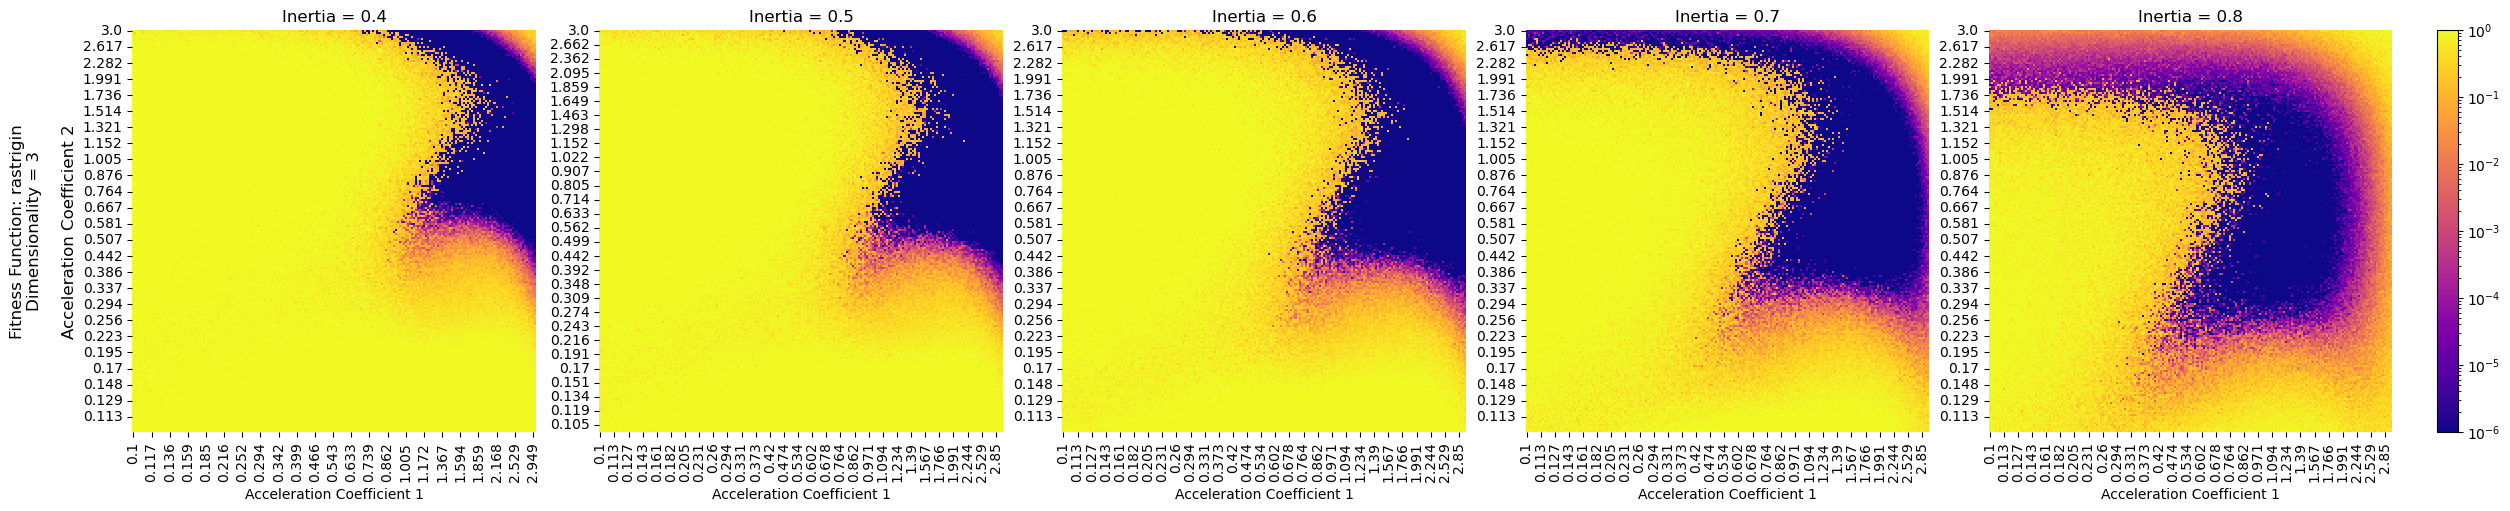

In [15]:
# 200x200, 20 samples
show_heatmaps('pso_rastrigin_low_resolution')

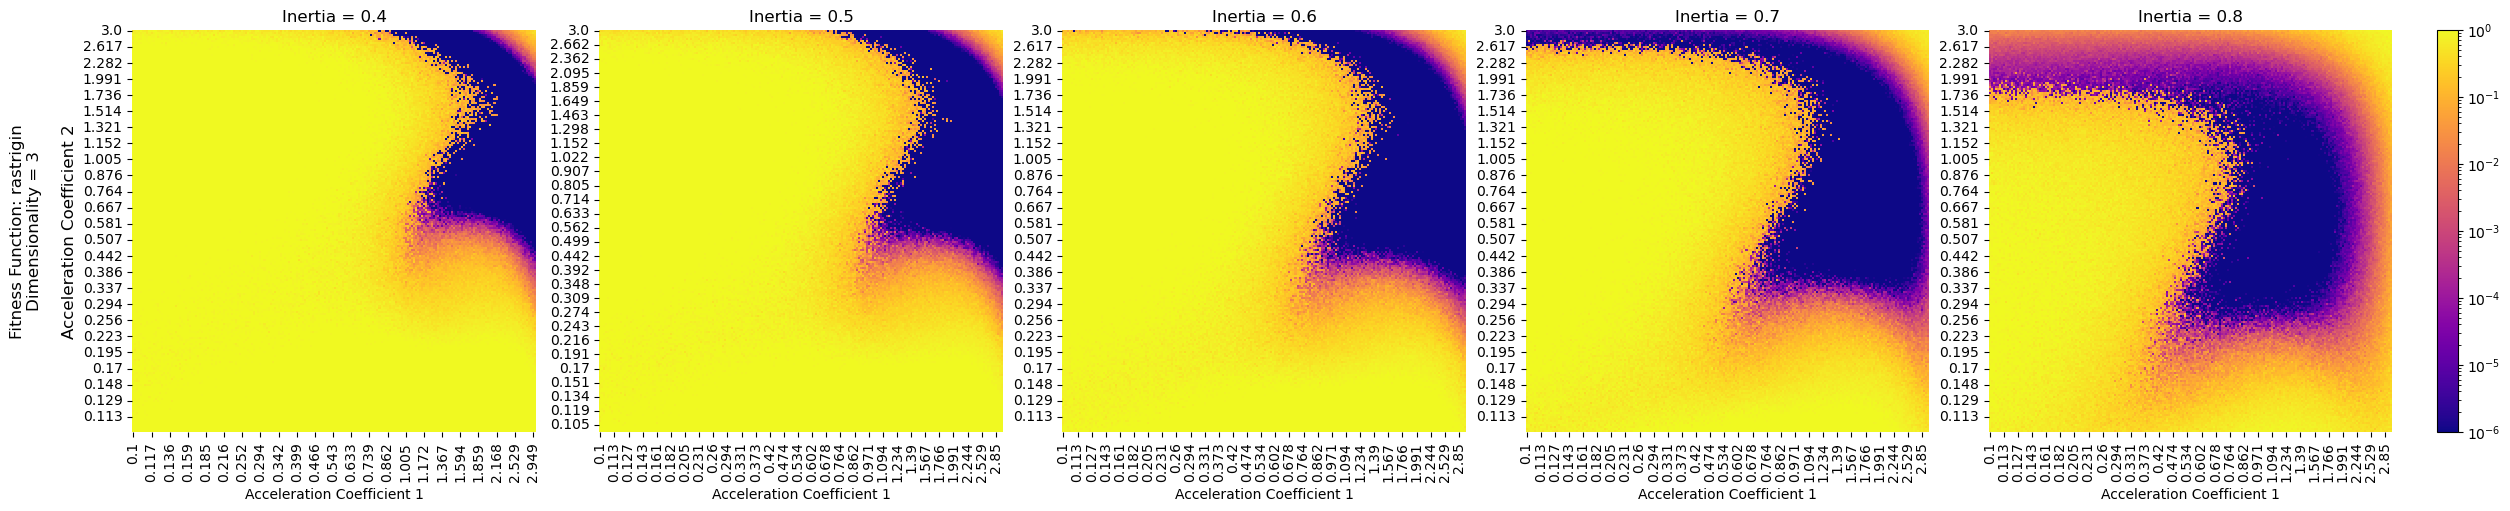

In [14]:
# 200x200, 50 samples
show_heatmaps('pso_rastrigin_medium_resolution')

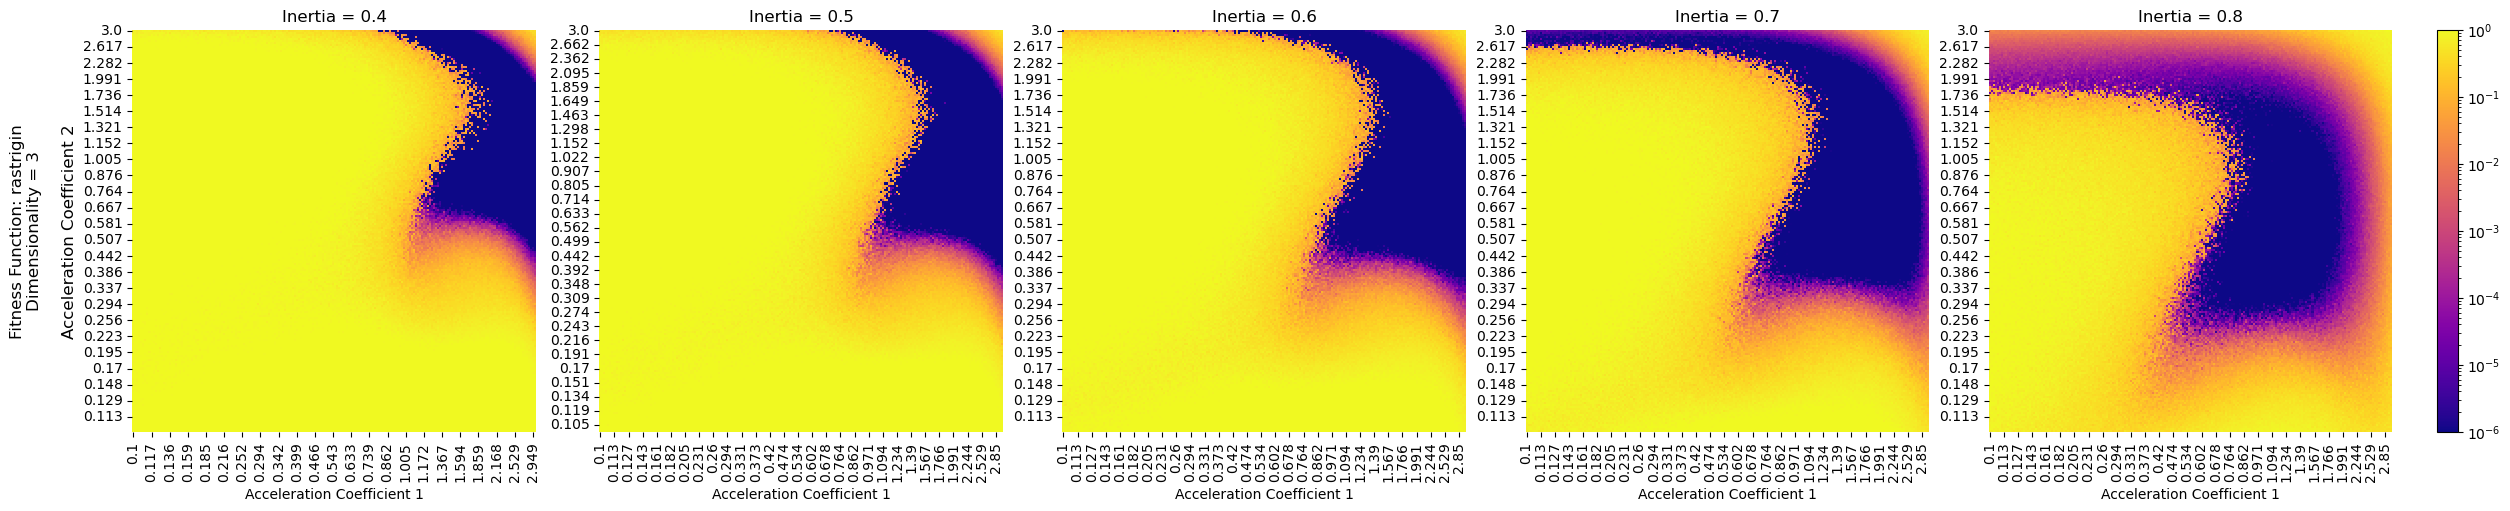

In [13]:
# 200x200, 100 samples
show_heatmaps('pso_rastrigin_high_resolution')

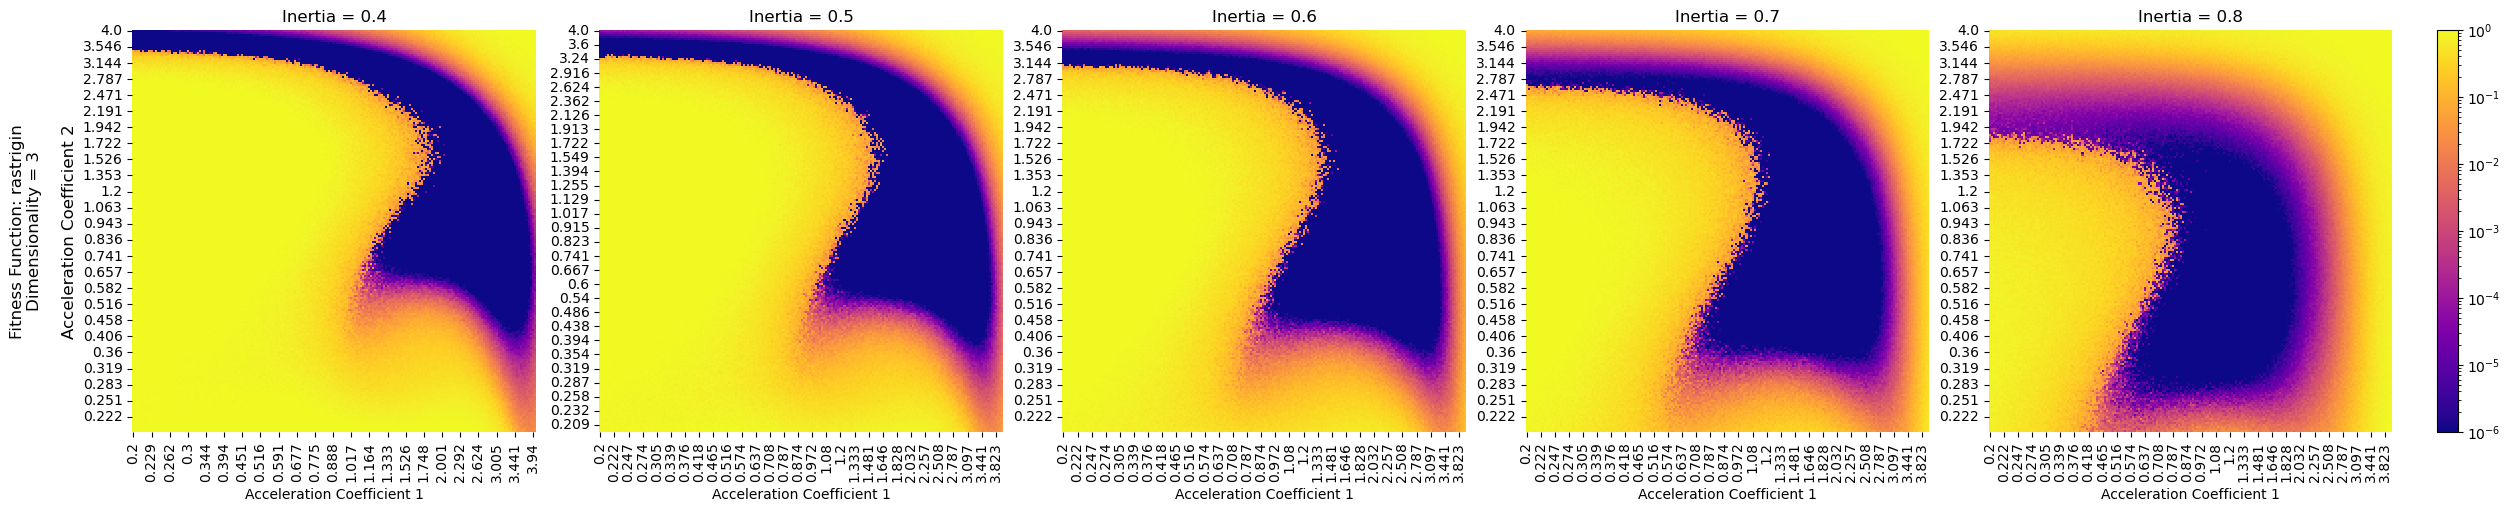

In [ ]:
# 200x200, 200 samples
show_heatmaps('pso_rastrigin_very_high_resolution')